In [1]:
import os
import cv2
import nibabel as nib
import numpy as np
import pandas as pd
from glob import glob

import torch
import torch.nn as nn
from torchvision import models

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


# Label changing


In [2]:
# import pandas as pd

# # Load original labels
# df = pd.read_csv(r"D:\Similiar_Colorectum\14004841\case_labels.csv")

# # Relabel
# df["label_binary"] = df["label"].map({2: 0, 3: 1})

# # Safety check
# print(df["label_binary"].value_counts())

# # Save new file
# out_path = r"D:\Similiar_Colorectum\14004841\case_labels_binary.csv"
# df[["case_id", "label_binary"]].to_csv(out_path, index=False)

# print("Saved binary labels to:", out_path)


# Loading Binary Labels

In [3]:
labels_df = pd.read_csv(
    r"D:\Similiar_Colorectum\14004841\case_labels_binary.csv"
)

print(labels_df["label_binary"].value_counts())


label_binary
0    86
1    30
Name: count, dtype: int64


# Tumor Slice Extraction (Baseline)

In [4]:
def get_tumor_slices(ct_path, mask_path):
    ct = nib.load(ct_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    slices = []
    for z in range(ct.shape[2]):
        if (mask[:, :, z] > 0).any():
            slices.append(ct[:, :, z])
    return slices


# Slice-Level Augmentation (CORE STEP)

We augment only tumor slices, before CNN.

In [5]:
def augment_slice(img):
    aug = []
    img = img.astype(np.float32)

    # Original
    aug.append(img)

    h, w = img.shape

    # Small rotation (+10°)
    M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1.0)
    aug.append(cv2.warpAffine(img, M, (w, h)))

    # Small rotation (-10°)
    M = cv2.getRotationMatrix2D((w//2, h//2), -10, 1.0)
    aug.append(cv2.warpAffine(img, M, (w, h)))

    # Horizontal flip
    aug.append(cv2.flip(img, 1))

    # Intensity scaling
    aug.append(img * 1.1)

    # Mild Gaussian noise
    noise = np.random.normal(0, 0.01, img.shape)
    aug.append(img + noise)

    return aug


# Augmented Tumor Slice Collection

In [6]:
def get_augmented_tumor_slices(ct_path, mask_path):
    slices = get_tumor_slices(ct_path, mask_path)
    all_slices = []
    for sl in slices:
        all_slices.extend(augment_slice(sl))
    return all_slices


# CNN Feature Extraction

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()
resnet = resnet.to(device)
resnet.eval()


c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
import torchvision.transforms as T

imagenet_norm = T.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)

def preprocess_slice(slice_img):
    # Convert to float32 numpy
    img = slice_img.astype(np.float32)

    # Robust clipping
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip(img, p1, p99)

    # Min-max normalize to [0,1]
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)

    # Convert to torch tensor WITH dtype=float32
    img = torch.from_numpy(img).float()     # 🔑 FIX IS HERE

    # Add channel & repeat to 3 channels
    img = img.unsqueeze(0).repeat(3, 1, 1)

    # ImageNet normalization
    img = imagenet_norm(img)

    return img


In [9]:
def extract_slice_features(slices, model):
    feats = []
    model.eval()

    with torch.no_grad():
        for sl in slices:
            t = preprocess_slice(sl).unsqueeze(0).to(device)
            f = model(t).cpu().numpy().squeeze()
            feats.append(f)

    return np.array(feats)


# MIL Pooling

In [10]:
def mil_topk_pool(features, k=5):
    norms = np.linalg.norm(features, axis=1)
    idx = np.argsort(norms)[-k:]
    return features[idx].mean(axis=0)

# Tumor Volume Feature

In [11]:
def compute_tumor_volume(mask_path):
    mask = nib.load(mask_path).get_fdata()
    return np.sum(mask > 0)

# Build FINAL Case-Level Dataset (X, y)

In [12]:
# IMG_DIR  = r"D:\Similiar_Colorectum\14004841\images\images"
# MASK_DIR = r"D:\Similiar_Colorectum\14004841\lms\lms"

# X, y = [], []

# for _, row in labels_df.iterrows():
#     case_id = row["case_id"]
#     label   = row["label_binary"]

#     ct = glob(f"{IMG_DIR}/crc_{case_id}_*.nii.gz")
#     mk = glob(f"{MASK_DIR}/crc_{case_id}_*.nii.gz")

#     if not ct or not mk:
#         continue

#     slices = get_augmented_tumor_slices(ct[0], mk[0])
#     feats  = extract_slice_features(slices, resnet)

#     case_feat = mil_topk_pool(feats, k=5)
#     volume = compute_tumor_volume(mk[0])

#     case_feat = np.concatenate([case_feat, [volume]])

#     X.append(case_feat)
#     y.append(label)

# X = np.array(X)
# y = np.array(y)

# print("X:", X.shape, "y:", y.shape)


In [13]:
# t = preprocess_slice(slices[0]).unsqueeze(0).to(device)
# print(t.dtype)        # should be torch.float32
# print(next(resnet.parameters()).dtype)  # torch.float32


In [14]:
# import pandas as pd

# df = pd.DataFrame(X)
# df["label"] = y

# csv_path = r"D:\Similiar_Colorectum\14004841\mil_features_augmented.csv"
# df.to_csv(csv_path, index=False)

# print("Saved CSV to:", csv_path)


In [15]:
import pandas as pd
import numpy as np

# Path to saved features CSV
csv_path = r"D:\Similiar_Colorectum\14004841\mil_features_augmented.csv"

# Load CSV
data_df = pd.read_csv(csv_path)

# Separate features and labels
X = data_df.drop(columns=["label"]).values
y = data_df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))


X shape: (116, 513)
y shape: (116,)
Unique labels: [0 1]


# MODELS

In [16]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Linear SVM": SVC(kernel="linear", class_weight="balanced"),
    "RBF SVM": SVC(kernel="rbf", class_weight="balanced"),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.05),
    "kNN": KNeighborsClassifier(n_neighbors=7)
}


# K-Fold with Mean ± Std

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score, f1_score
import numpy as np
import pandas as pd

def evaluate_kfold_with_probs(
    model, X, y, model_name,
    use_pca=False
):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # ---- store per-fold metrics ----
    fold_metrics = []

    # ---- store ALL predictions ----
    y_true_all = []
    y_pred_all = []
    y_prob_all = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

        # Split
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Scale
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)

        # PCA (optional)
        if use_pca:
            pca = PCA(n_components=0.95)
            X_train = pca.fit_transform(X_train)
            X_val   = pca.transform(X_val)

        # Train
        model.fit(X_train, y_train)

        # Predict labels
        y_pred = model.predict(X_val)

        # Predict probabilities (IMPORTANT)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_val)[:, 1]
        else:
            # fallback (for models without predict_proba)
            y_prob = model.decision_function(X_val)
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-6)

        # Store global predictions
        y_true_all.extend(y_val)
        y_pred_all.extend(y_pred)
        y_prob_all.extend(y_prob)

        # Fold metrics
        fold_metrics.append({
            "Model": model_name,
            "Fold": fold,
            "Accuracy": accuracy_score(y_val, y_pred),
            "Recall_Malignant": recall_score(y_val, y_pred),
            "Macro_F1": f1_score(y_val, y_pred, average="macro"),
            "PCA": use_pca
        })

    return (
        pd.DataFrame(fold_metrics),
        np.array(y_true_all),
        np.array(y_pred_all),
        np.array(y_prob_all)
    )


# RUN EXPERIMENTS (PCA + No PCA)

In [18]:
all_folds_no_pca = []

# To store predictions for plots
y_true_all_no_pca = []
y_pred_all_no_pca = []
y_prob_all_no_pca = []

for name, model in models.items():
    fold_df, y_true, y_pred, y_prob = evaluate_kfold_with_probs(
        model, X, y, model_name=name, use_pca=False
    )

    all_folds_no_pca.append(fold_df)

    y_true_all_no_pca.extend(y_true)
    y_pred_all_no_pca.extend(y_pred)
    y_prob_all_no_pca.extend(y_prob)

all_folds_df_no_pca = pd.concat(all_folds_no_pca, ignore_index=True)
all_folds_df_no_pca


c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\subprocess.py", line

,Model,Fold,Accuracy,Recall_Malignant,Macro_F1,PCA
0,Logistic Regression,1,0.833333,0.666667,0.777778,False
1,Logistic Regression,2,0.782609,0.500000,0.701299,False
2,Logistic Regression,3,0.739130,0.500000,0.661765,False
3,Logistic Regression,4,0.521739,0.500000,0.486815,False
4,Logistic Regression,5,0.826087,0.333333,0.697368,False
5,Linear SVM,1,0.833333,0.666667,0.777778,False
6,Linear SVM,2,0.782609,0.500000,0.701299,False
7,Linear SVM,3,0.739130,0.500000,0.661765,False
8,Linear SVM,4,0.565217,0.500000,0.520833,False
9,Linear SVM,5,0.826087,0.333333,0.697368,False


In [19]:
all_folds_pca = []

y_true_all_pca = []
y_pred_all_pca = []
y_prob_all_pca = []

for name, model in models.items():
    fold_df, y_true, y_pred, y_prob = evaluate_kfold_with_probs(
        model, X, y, model_name=name, use_pca=True
    )

    all_folds_pca.append(fold_df)

    y_true_all_pca.extend(y_true)
    y_pred_all_pca.extend(y_pred)
    y_prob_all_pca.extend(y_prob)

all_folds_df_pca = pd.concat(all_folds_pca, ignore_index=True)
all_folds_df_pca



,Model,Fold,Accuracy,Recall_Malignant,Macro_F1,PCA
0,Logistic Regression,1,0.791667,0.500000,0.705160,True
1,Logistic Regression,2,0.695652,0.500000,0.624709,True
2,Logistic Regression,3,0.695652,0.500000,0.624709,True
3,Logistic Regression,4,0.608696,0.666667,0.580122,True
4,Logistic Regression,5,0.782609,0.333333,0.654655,True
5,Linear SVM,1,0.791667,0.500000,0.705160,True
6,Linear SVM,2,0.652174,0.500000,0.589286,True
7,Linear SVM,3,0.695652,0.500000,0.624709,True
8,Linear SVM,4,0.565217,0.666667,0.543651,True
9,Linear SVM,5,0.782609,0.166667,0.578755,True


# PER-CLASS METRICS FUNCTION

In [20]:
from sklearn.metrics import classification_report
import pandas as pd

def get_per_class_metrics(y_true, y_pred, model_name):
    report = classification_report(
        y_true, y_pred,
        target_names=["Benign (0)", "Malignant (1)"],
        output_dict=True
    )

    df = pd.DataFrame({
        "Model": model_name,
        "Precision_0": report["Benign (0)"]["precision"],
        "Recall_0": report["Benign (0)"]["recall"],
        "F1_0": report["Benign (0)"]["f1-score"],
        "Precision_1": report["Malignant (1)"]["precision"],
        "Recall_1": report["Malignant (1)"]["recall"],
        "F1_1": report["Malignant (1)"]["f1-score"],
        "Macro_F1": report["macro avg"]["f1-score"],
        "Accuracy": report["accuracy"]
    }, index=[0])

    return df


In [21]:
# NO PCA

all_model_metrics = []

for name, model in models.items():
    _, y_true, y_pred, _ = evaluate_kfold_with_probs(
        model, X, y,
        model_name=name,
        use_pca=False
    )

    df_metrics = get_per_class_metrics(y_true, y_pred, name)
    df_metrics["PCA"] = False   # ⭐ ADD THIS
    all_model_metrics.append(df_metrics)

final_metrics_df_no_pca = pd.concat(all_model_metrics, ignore_index=True)



# PCA

all_model_metrics = []

for name, model in models.items():
    _, y_true, y_pred, _ = evaluate_kfold_with_probs(
        model, X, y,
        model_name=name,
        use_pca=True
    )

    df_metrics = get_per_class_metrics(y_true, y_pred, name)
    df_metrics["PCA"] = True    # ⭐ ADD THIS
    all_model_metrics.append(df_metrics)

final_metrics_df_pca = pd.concat(all_model_metrics, ignore_index=True)


final_metrics_df = pd.concat(
    [final_metrics_df_no_pca, final_metrics_df_pca],
    ignore_index=True
)

final_metrics_df



,Model,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,Accuracy,PCA
0,Logistic Regression,0.825581,0.825581,0.825581,0.500000,0.500000,0.500000,0.662791,0.741379,False
1,Linear SVM,0.827586,0.837209,0.832370,0.517241,0.500000,0.508475,0.670422,0.750000,False
2,RBF SVM,0.762376,0.895349,0.823529,0.400000,0.200000,0.266667,0.545098,0.715517,False
3,Naive Bayes,0.828947,0.732558,0.777778,0.425000,0.566667,0.485714,0.631746,0.689655,False
4,LDA,0.802817,0.662791,0.726115,0.355556,0.533333,0.426667,0.576391,0.629310,False
5,Random Forest,0.752212,0.988372,0.854271,0.666667,0.066667,0.121212,0.487742,0.750000,False
6,Gradient Boosting,0.818182,0.941860,0.875676,0.705882,0.400000,0.510638,0.693157,0.801724,False
7,kNN,0.745283,0.918605,0.822917,0.300000,0.100000,0.150000,0.486458,0.706897,False
8,Logistic Regression,0.819277,0.790698,0.804734,0.454545,0.500000,0.476190,0.640462,0.715517,True
9,Linear SVM,0.807229,0.779070,0.792899,0.424242,0.466667,0.444444,0.618672,0.698276,True


In [22]:
# Find best model WITHOUT PCA

best_no_pca = (
    final_metrics_df
    [final_metrics_df["PCA"] == False]
    .sort_values(
        by=["Recall_1", "F1_1", "Macro_F1", "Accuracy"],
        ascending=False
    )
)

best_no_pca


,Model,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,Accuracy,PCA
3,Naive Bayes,0.828947,0.732558,0.777778,0.425000,0.566667,0.485714,0.631746,0.689655,False
4,LDA,0.802817,0.662791,0.726115,0.355556,0.533333,0.426667,0.576391,0.629310,False
1,Linear SVM,0.827586,0.837209,0.832370,0.517241,0.500000,0.508475,0.670422,0.750000,False
0,Logistic Regression,0.825581,0.825581,0.825581,0.500000,0.500000,0.500000,0.662791,0.741379,False
6,Gradient Boosting,0.818182,0.941860,0.875676,0.705882,0.400000,0.510638,0.693157,0.801724,False
2,RBF SVM,0.762376,0.895349,0.823529,0.400000,0.200000,0.266667,0.545098,0.715517,False
7,kNN,0.745283,0.918605,0.822917,0.300000,0.100000,0.150000,0.486458,0.706897,False
5,Random Forest,0.752212,0.988372,0.854271,0.666667,0.066667,0.121212,0.487742,0.750000,False


In [23]:
# PCA best model sorting

best_with_pca = (
    final_metrics_df
    [final_metrics_df["PCA"] == True]
    .sort_values(
        by=["Recall_1", "F1_1", "Macro_F1", "Accuracy"],
        ascending=False
    )
)

best_with_pca



,Model,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,Accuracy,PCA
8,Logistic Regression,0.819277,0.790698,0.804734,0.454545,0.500000,0.476190,0.640462,0.715517,True
12,LDA,0.816092,0.825581,0.820809,0.482759,0.466667,0.474576,0.647693,0.732759,True
9,Linear SVM,0.807229,0.779070,0.792899,0.424242,0.466667,0.444444,0.618672,0.698276,True
10,RBF SVM,0.813187,0.860465,0.836158,0.520000,0.433333,0.472727,0.654443,0.750000,True
11,Naive Bayes,0.758242,0.802326,0.779661,0.320000,0.266667,0.290909,0.535285,0.663793,True
14,Gradient Boosting,0.759259,0.953488,0.845361,0.500000,0.133333,0.210526,0.527944,0.741379,True
13,Random Forest,0.754386,1.000000,0.860000,1.000000,0.066667,0.125000,0.492500,0.758621,True
15,kNN,0.740741,0.930233,0.824742,0.250000,0.066667,0.105263,0.465003,0.706897,True


In [24]:
print("Best model WITHOUT PCA:")
display(best_no_pca.head(1))

print("\nBest model WITH PCA:")
display(best_with_pca.head(1))


Best model WITHOUT PCA:


,Model,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,Accuracy,PCA
3,Naive Bayes,0.828947,0.732558,0.777778,0.425,0.566667,0.485714,0.631746,0.689655,False



Best model WITH PCA:


,Model,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,Macro_F1,Accuracy,PCA
8,Logistic Regression,0.819277,0.790698,0.804734,0.454545,0.5,0.47619,0.640462,0.715517,True


## GETTING `y_true_no_pca, y_pred_no_pca` FOR CONFUSION MATRIX

Best NO PCA model: Naive Bayes
Best WITH PCA model: Logistic Regression


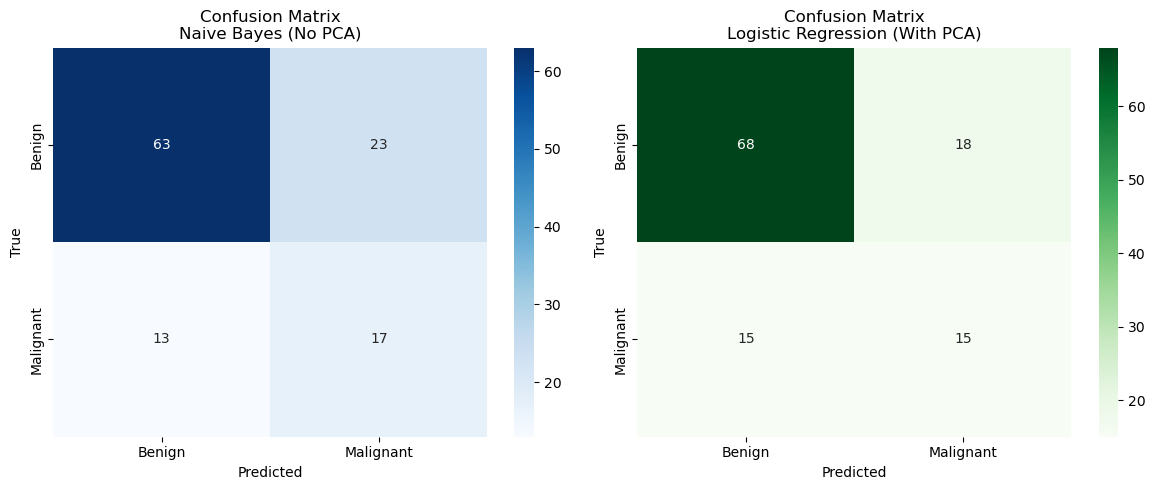

In [25]:
best_model_no_pca_name  = best_no_pca.iloc[0]["Model"]
best_model_pca_name     = best_with_pca.iloc[0]["Model"]

print("Best NO PCA model:", best_model_no_pca_name)
print("Best WITH PCA model:", best_model_pca_name)

best_model_no_pca  = models[best_model_no_pca_name]
best_model_with_pca = models[best_model_pca_name]

_, y_true_no_pca, y_pred_no_pca, y_prob_no_pca = evaluate_kfold_with_probs(
    best_model_no_pca,
    X,
    y,
    model_name=best_model_no_pca_name,
    use_pca=False
)

_, y_true_pca, y_pred_pca, y_prob_pca = evaluate_kfold_with_probs(
    best_model_with_pca,
    X,
    y,
    model_name=best_model_pca_name,
    use_pca=True
)



cm_no_pca = confusion_matrix(y_true_no_pca, y_pred_no_pca)
cm_pca    = confusion_matrix(y_true_pca, y_pred_pca)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- NO PCA ----
sns.heatmap(
    cm_no_pca,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=axes[0]
)
axes[0].set_title(f"Confusion Matrix\n{best_model_no_pca_name} (No PCA)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# ---- WITH PCA ----
sns.heatmap(
    cm_pca,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=axes[1]
)
axes[1].set_title(f"Confusion Matrix\n{best_model_pca_name} (With PCA)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()




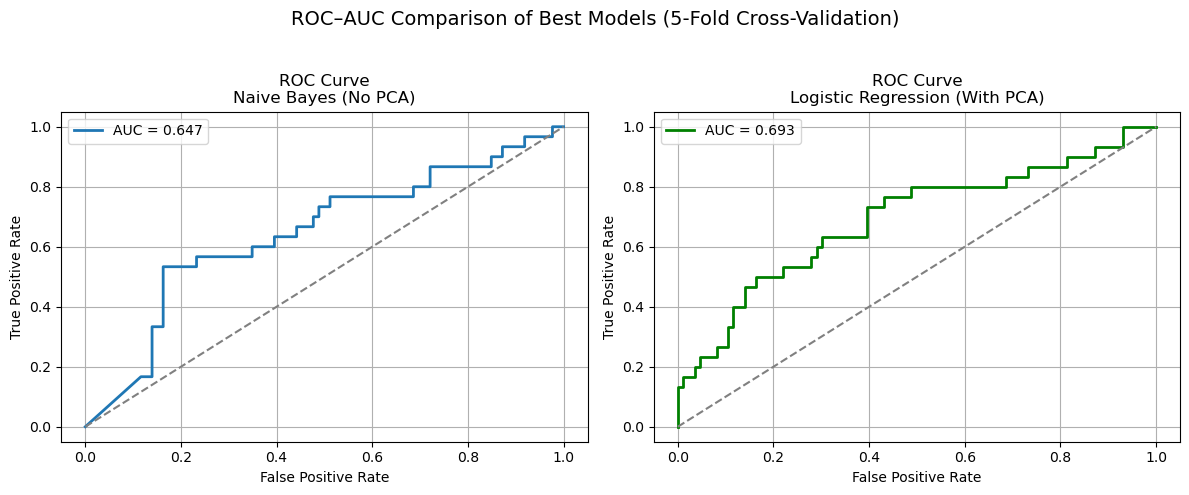

In [26]:
from sklearn.metrics import roc_curve, auc

# NO PCA
fpr_no, tpr_no, _ = roc_curve(y_true_no_pca, y_prob_no_pca)
auc_no = auc(fpr_no, tpr_no)

# WITH PCA
fpr_pca, tpr_pca, _ = roc_curve(y_true_pca, y_prob_pca)
auc_pca = auc(fpr_pca, tpr_pca)


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].plot(fpr_no, tpr_no, label=f"AUC = {auc_no:.3f}", linewidth=2)
axes[0].plot([0, 1], [0, 1], '--', color='gray')

axes[0].set_title(f"ROC Curve\n{best_model_no_pca_name} (No PCA)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(fpr_pca, tpr_pca, label=f"AUC = {auc_pca:.3f}", linewidth=2, color="green")
axes[1].plot([0, 1], [0, 1], '--', color='gray')

axes[1].set_title(f"ROC Curve\n{best_model_pca_name} (With PCA)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True)


plt.suptitle(
    "ROC–AUC Comparison of Best Models (5-Fold Cross-Validation)",
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Feature Importance (Linear SVM)

In [27]:
svm = SVC(kernel="linear", class_weight="balanced")
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

svm.fit(Xs, y)
importance = np.abs(svm.coef_).flatten()

print("Top important feature indices:", np.argsort(importance)[-10:])
print("Tumor volume importance:", importance[-1])


Top important feature indices: [456 156  99 151 168 445  89 466 379 512]
Tumor volume importance: 0.10701650583666224


# Accuracy vs K-Fold (per model)

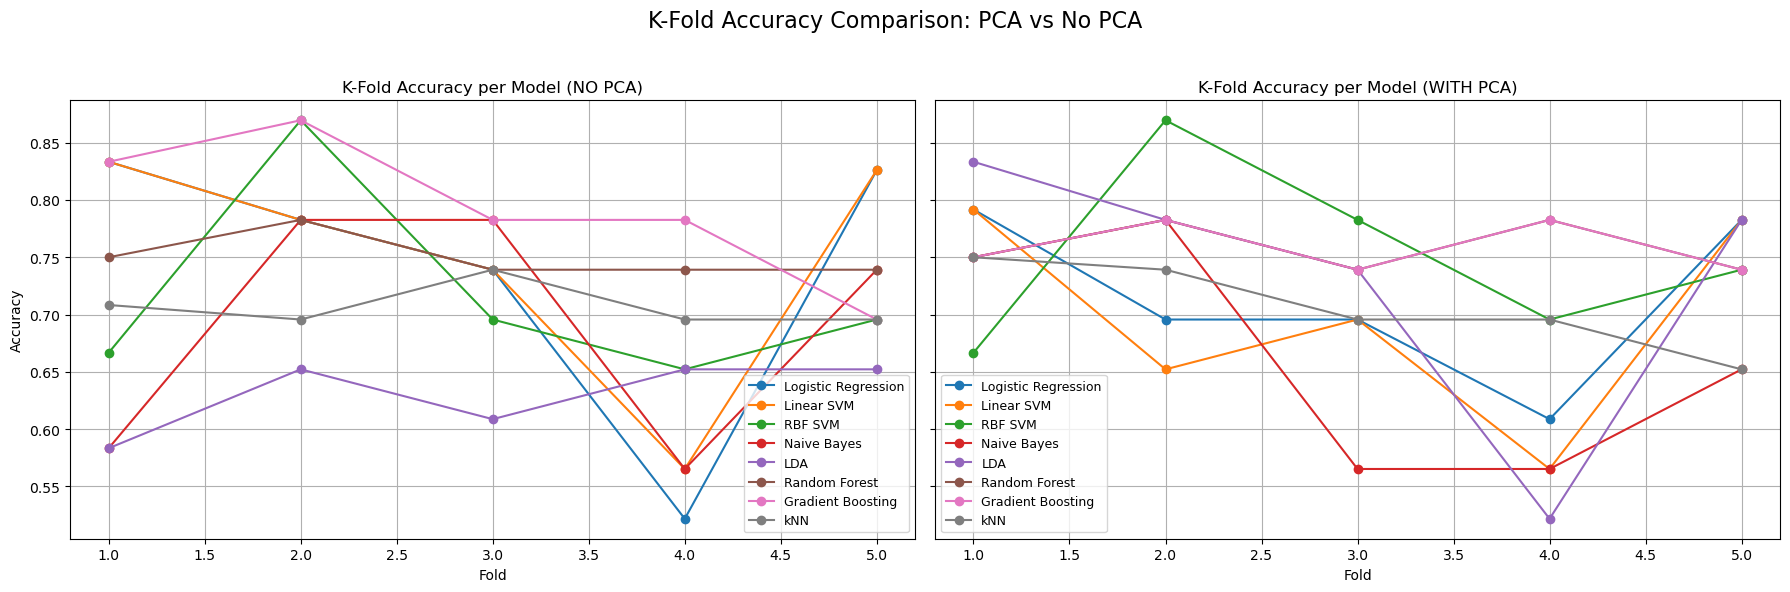

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)


for model in all_folds_df_no_pca["Model"].unique():
    subset = all_folds_df_no_pca[
        all_folds_df_no_pca["Model"] == model
    ]
    axes[0].plot(
        subset["Fold"],
        subset["Accuracy"],
        marker='o',
        label=model
    )

axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("K-Fold Accuracy per Model (NO PCA)")
axes[0].grid(True)
axes[0].legend(fontsize=9)


for model in all_folds_df_pca["Model"].unique():
    subset = all_folds_df_pca[
        all_folds_df_pca["Model"] == model
    ]
    axes[1].plot(
        subset["Fold"],
        subset["Accuracy"],
        marker='o',
        label=model
    )

axes[1].set_xlabel("Fold")
axes[1].set_title("K-Fold Accuracy per Model (WITH PCA)")
axes[1].grid(True)
axes[1].legend(fontsize=9)

plt.suptitle(
    "K-Fold Accuracy Comparison: PCA vs No PCA",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Boxplot (Accuracy distribution across folds)

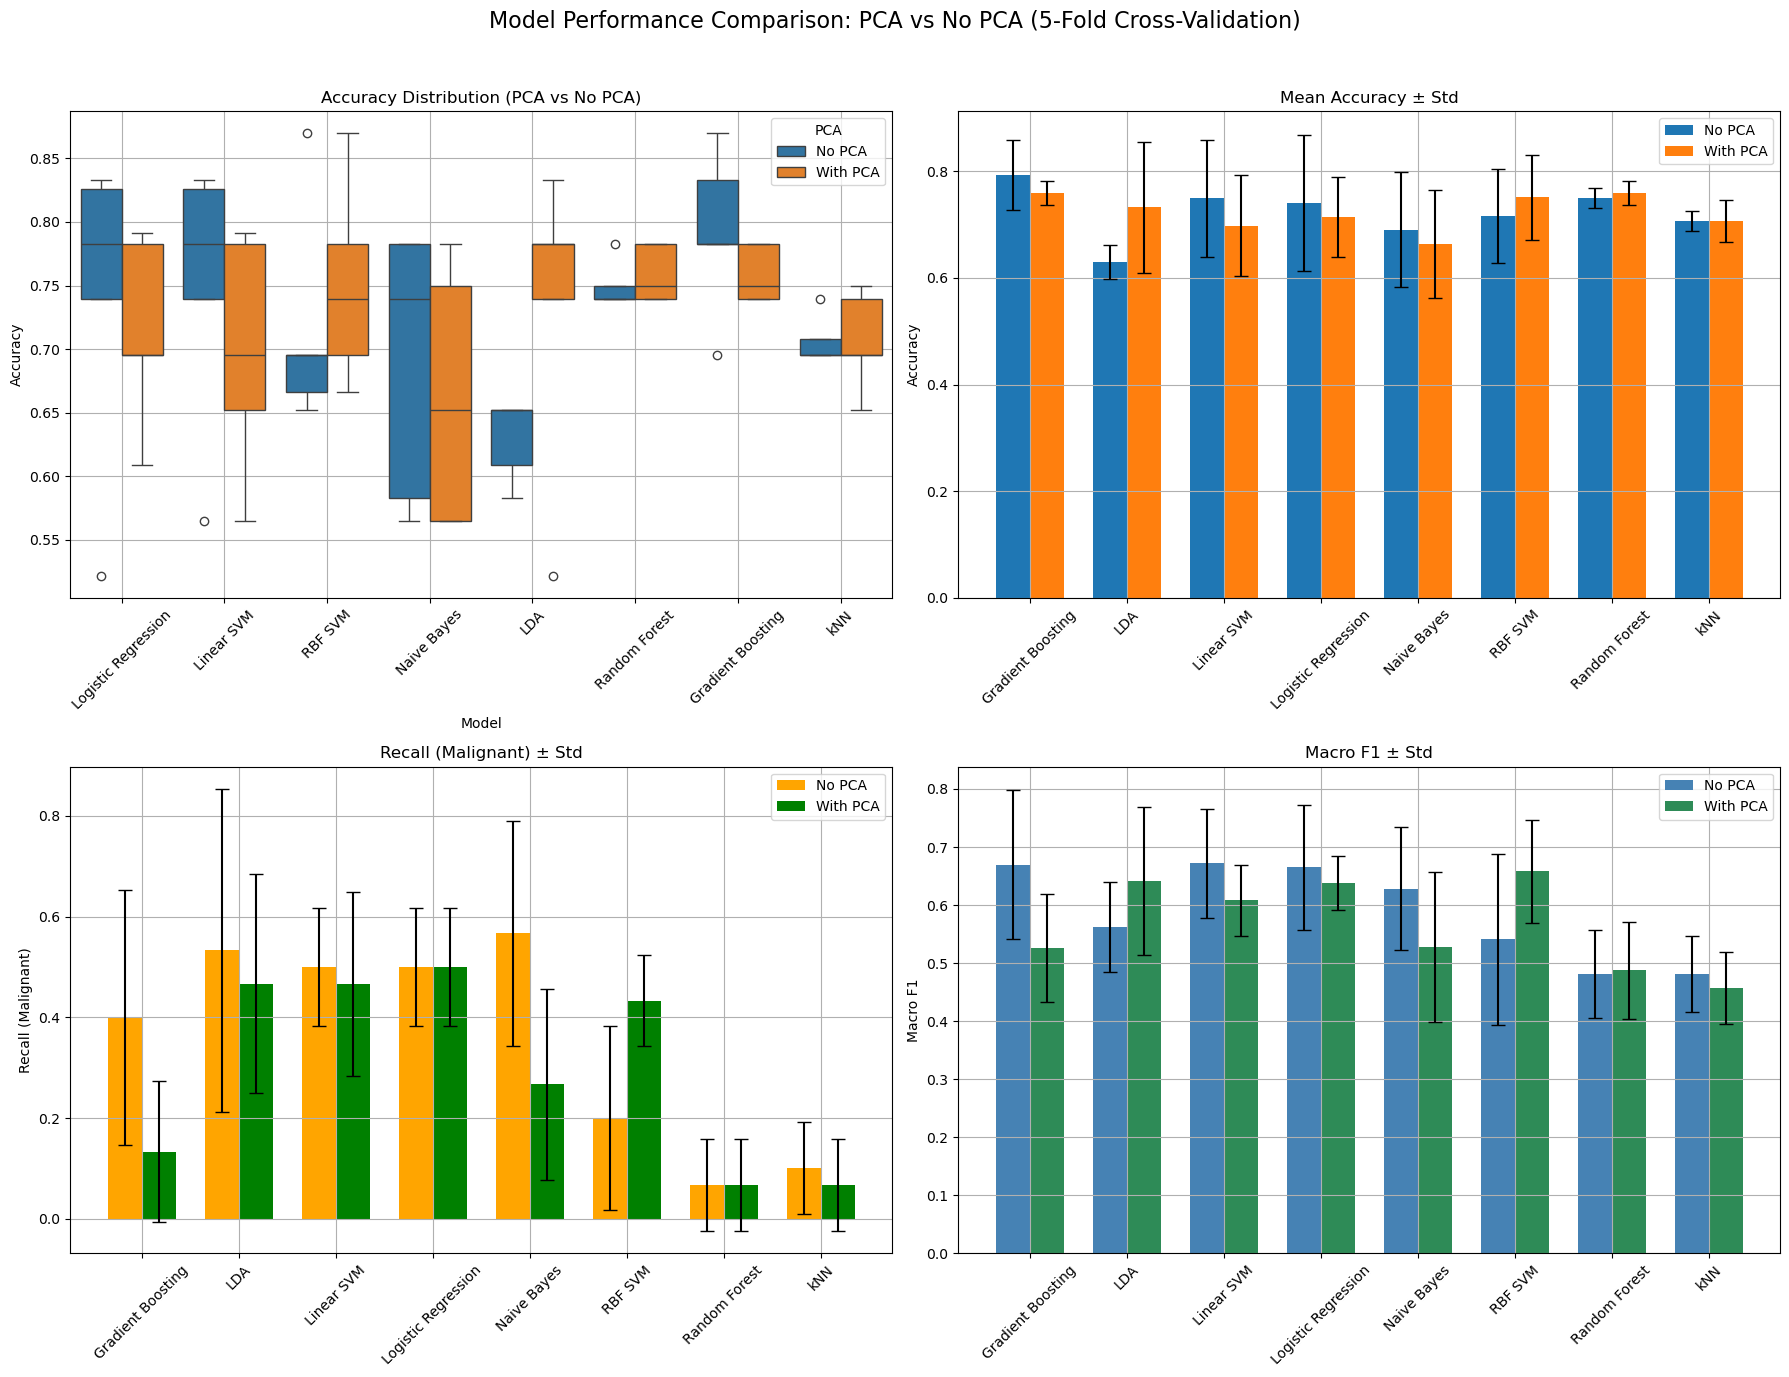

In [29]:
df_no = all_folds_df_no_pca.copy()
df_no["PCA"] = "No PCA"

df_pca = all_folds_df_pca.copy()
df_pca["PCA"] = "With PCA"

combined_df = pd.concat([df_no, df_pca], ignore_index=True)


df_no = all_folds_df_no_pca.copy()
df_no["PCA"] = "No PCA"

df_pca = all_folds_df_pca.copy()
df_pca["PCA"] = "With PCA"

combined_df = pd.concat([df_no, df_pca], ignore_index=True)


acc_summary = combined_df.groupby(["Model", "PCA"])["Accuracy"].agg(["mean", "std"]).reset_index()
rec_summary = combined_df.groupby(["Model", "PCA"])["Recall_Malignant"].agg(["mean", "std"]).reset_index()
f1_summary  = combined_df.groupby(["Model", "PCA"])["Macro_F1"].agg(["mean", "std"]).reset_index()


fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.boxplot(
    data=combined_df,
    x="Model",
    y="Accuracy",
    hue="PCA",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Accuracy Distribution (PCA vs No PCA)")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True)


x = np.arange(len(acc_summary["Model"].unique()))
width = 0.35
models = acc_summary["Model"].unique()

no_pca = acc_summary[acc_summary["PCA"] == "No PCA"]
pca    = acc_summary[acc_summary["PCA"] == "With PCA"]

axes[0, 1].bar(
    x - width/2,
    no_pca["mean"],
    width,
    yerr=no_pca["std"],
    capsize=5,
    label="No PCA"
)

axes[0, 1].bar(
    x + width/2,
    pca["mean"],
    width,
    yerr=pca["std"],
    capsize=5,
    label="With PCA"
)

axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=45)
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Mean Accuracy ± Std")
axes[0, 1].legend()
axes[0, 1].grid(True)

no_pca = rec_summary[rec_summary["PCA"] == "No PCA"]
pca    = rec_summary[rec_summary["PCA"] == "With PCA"]

axes[1, 0].bar(
    x - width/2,
    no_pca["mean"],
    width,
    yerr=no_pca["std"],
    capsize=5,
    label="No PCA",
    color="orange"
)

axes[1, 0].bar(
    x + width/2,
    pca["mean"],
    width,
    yerr=pca["std"],
    capsize=5,
    label="With PCA",
    color="green"
)

axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=45)
axes[1, 0].set_ylabel("Recall (Malignant)")
axes[1, 0].set_title("Recall (Malignant) ± Std")
axes[1, 0].legend()
axes[1, 0].grid(True)



no_pca = f1_summary[f1_summary["PCA"] == "No PCA"]
pca    = f1_summary[f1_summary["PCA"] == "With PCA"]

axes[1, 1].bar(
    x - width/2,
    no_pca["mean"],
    width,
    yerr=no_pca["std"],
    capsize=5,
    label="No PCA",
    color="steelblue"
)

axes[1, 1].bar(
    x + width/2,
    pca["mean"],
    width,
    yerr=pca["std"],
    capsize=5,
    label="With PCA",
    color="seagreen"
)

axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=45)
axes[1, 1].set_ylabel("Macro F1")
axes[1, 1].set_title("Macro F1 ± Std")
axes[1, 1].legend()
axes[1, 1].grid(True)


plt.suptitle(
    "Model Performance Comparison: PCA vs No PCA (5-Fold Cross-Validation)",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

summary = (
    final_metrics_df
    .groupby(["Model", "PCA"])
    .mean(numeric_only=True)
    .reset_index()
)

models = summary["Model"].unique()
x = np.arange(len(models))
width = 0.35


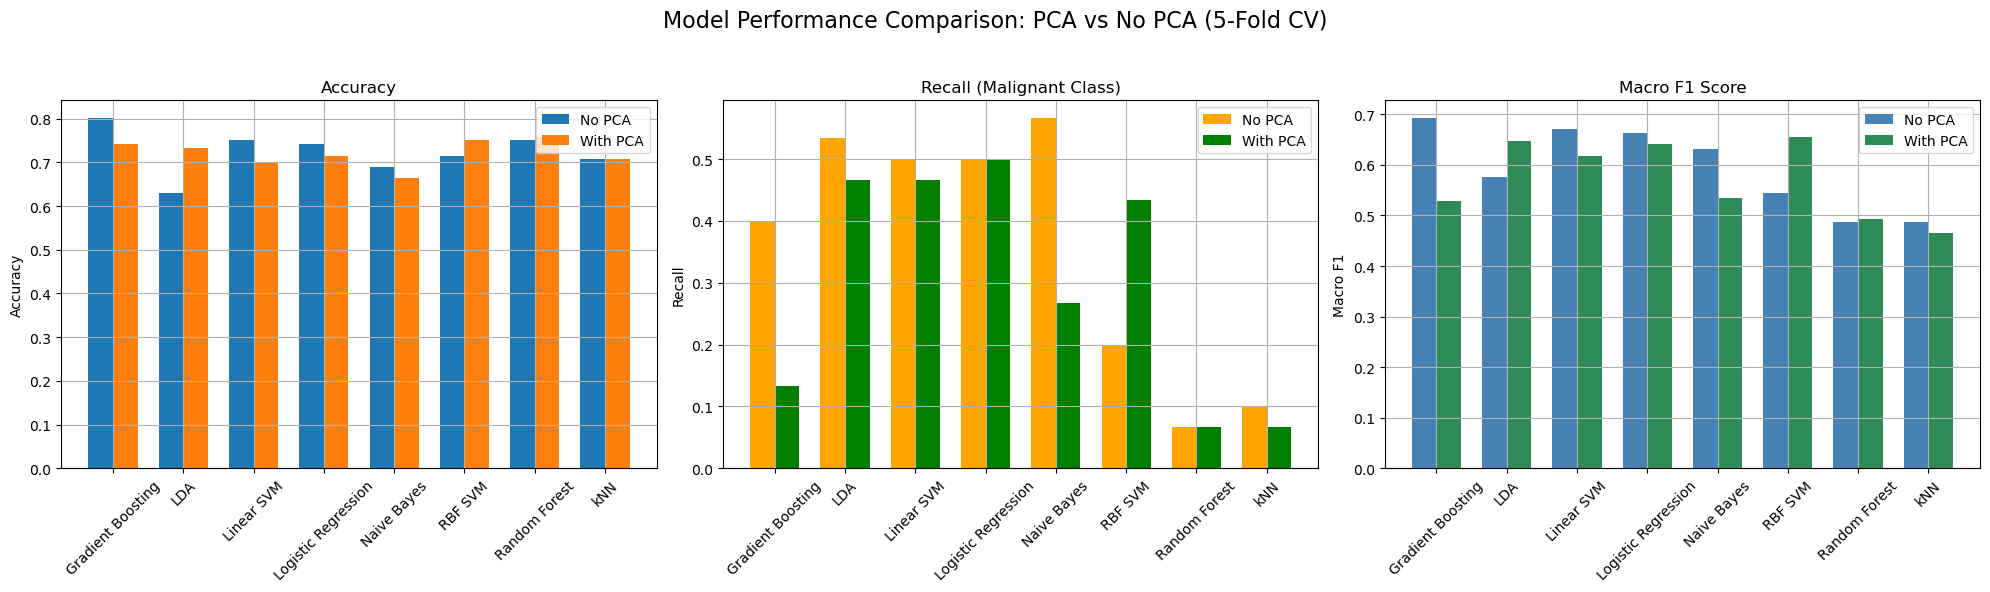

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)

acc_no_pca = summary[summary["PCA"] == False]["Accuracy"].values
acc_pca    = summary[summary["PCA"] == True]["Accuracy"].values

axes[0].bar(x - width/2, acc_no_pca, width, label="No PCA")
axes[0].bar(x + width/2, acc_pca,    width, label="With PCA")

axes[0].set_title("Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45)
axes[0].grid(True)
axes[0].legend()

rec_no_pca = summary[summary["PCA"] == False]["Recall_1"].values
rec_pca    = summary[summary["PCA"] == True]["Recall_1"].values

axes[1].bar(x - width/2, rec_no_pca, width, label="No PCA", color="orange")
axes[1].bar(x + width/2, rec_pca,    width, label="With PCA", color="green")

axes[1].set_title("Recall (Malignant Class)")
axes[1].set_ylabel("Recall")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45)
axes[1].grid(True)
axes[1].legend()

f1_no_pca = summary[summary["PCA"] == False]["Macro_F1"].values
f1_pca    = summary[summary["PCA"] == True]["Macro_F1"].values

axes[2].bar(x - width/2, f1_no_pca, width, label="No PCA", color="steelblue")
axes[2].bar(x + width/2, f1_pca,    width, label="With PCA", color="seagreen")

axes[2].set_title("Macro F1 Score")
axes[2].set_ylabel("Macro F1")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45)
axes[2].grid(True)
axes[2].legend()

plt.suptitle(
    "Model Performance Comparison: PCA vs No PCA (5-Fold CV)",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Confusion Matrix (per model, aggregated)

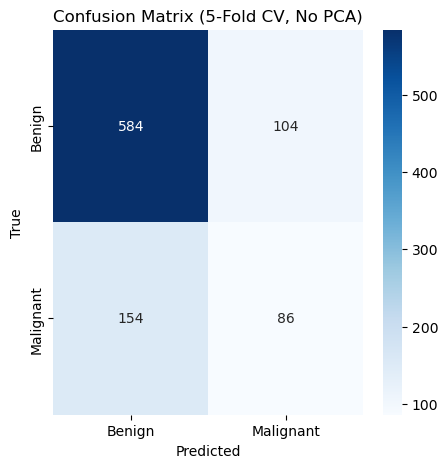

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_all_no_pca, y_pred_all_no_pca)

plt.figure(figsize=(5,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (5-Fold CV, No PCA)")
plt.show()


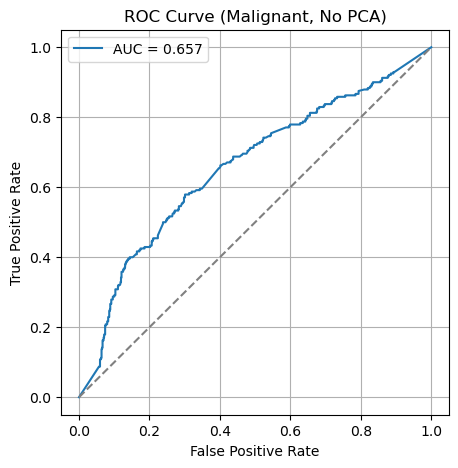

In [33]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true_all_no_pca, y_prob_all_no_pca)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Malignant, No PCA)")
plt.legend()
plt.grid(True)
plt.show()
